<a href="https://colab.research.google.com/github/BrendJ510/Proyectos-Escolares/blob/main/RedNeuronalIris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# 1. Cargar Datos
iris = sns.load_dataset('iris')

In [ ]:
# Separar X (Características) y Y (Etiquetas)
X = iris.drop('species', axis=1)
Y_text = iris['species']

In [ ]:
# 2. Preprocesamiento de Etiquetas (De texto a números)
# Iris tiene 'setosa', 'versicolor', etc. La red necesita números.
encoder = LabelEncoder()
Y_encoded = encoder.fit_transform(Y_text) # Convierte a 0, 1, 2
Y_cat = to_categorical(Y_encoded) # Convierte a [1,0,0], [0,1,0], etc.

In [ ]:
# 3. Preprocesamiento de X (Normalización)
# Es buena práctica escalar los datos para que la red aprenda mejor
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

In [ ]:
# 4. División de datos (Train, Val, Test)
# Primero separamos Test (15%)
X_train, X_test, y_train, y_test = train_test_split(X_norm, Y_cat, test_size=0.15, shuffle=True, random_state=42)
# Del resto, separamos Validación (15%)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, shuffle=True, random_state=42)

In [ ]:
# 5. Definir Arquitectura (Red Neuronal Densa)
model = Sequential([
    # Input shape es 4 porque tenemos 4 columnas de datos
    Dense(64, activation='relu', input_shape=(4,)),
    Dropout(0.2), # Ayuda a prevenir overfitting
    Dense(64, activation='relu'),
    # Capa de salida: 3 neuronas (3 especies de flores)
    Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,675 (18.26 KB)

 Trainable params: 4,675 (18.26 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 6. Compilación y Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# 7. Entrenamiento
history = model.fit(X_train, y_train,
                    epochs=200, # Iris necesita menos epochs que imágenes usualmente
                    batch_size=16, # Batch size más pequeño porque el dataset es chico (150 datos)
                    validation_data=(X_val, y_val),
                    callbacks=[early_stopping],
                    verbose=1)

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.2955 - loss: 1.1516 - val_accuracy: 0.5500 - val_loss: 0.9582
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6054 - loss: 0.9546 - val_accuracy: 0.7500 - val_loss: 0.7987
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7620 - loss: 0.7709 - val_accuracy: 0.7500 - val_loss: 0.6837
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7577 - loss: 0.6857 - val_accuracy: 0.8500 - val_loss: 0.5970
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7722 - loss: 0.6099 - val_accuracy: 0.8500 - val_loss: 0.5277
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8072 - loss: 0.5289 - val_accuracy: 0.8500 - val_loss: 0.4693
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7993 - loss: 0.5029 - val_accuracy: 0.8500 - val_loss: 0.4223
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8268 - loss: 0.4056 - val_accuracy: 0.8500 - val_loss:

In [ ]:
# 8. Evaluación
score = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {score[1]}')
print(f'Test Loss: {score[0]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.0387
Test Accuracy: 1.0
Test Loss: 0.038728538900613785


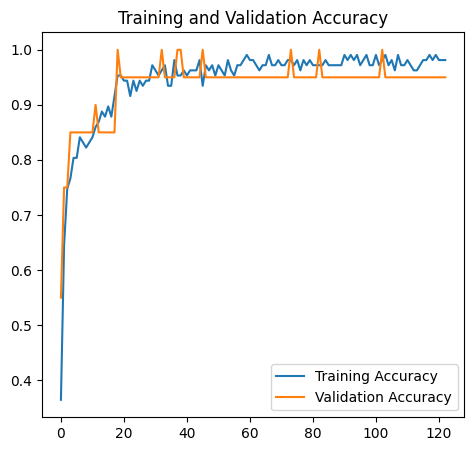

In [ ]:
# Gráfica de Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

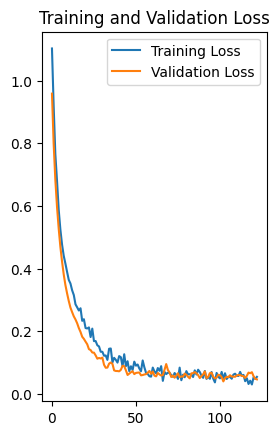

In [ ]:
# Gráfica de Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
# --- PREDICCIONES Y MATRIZ DE CONFUSIÓN ---
y_pred = np.argmax(model.predict(X_test), axis=1)
Y_true = np.argmax(y_test, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


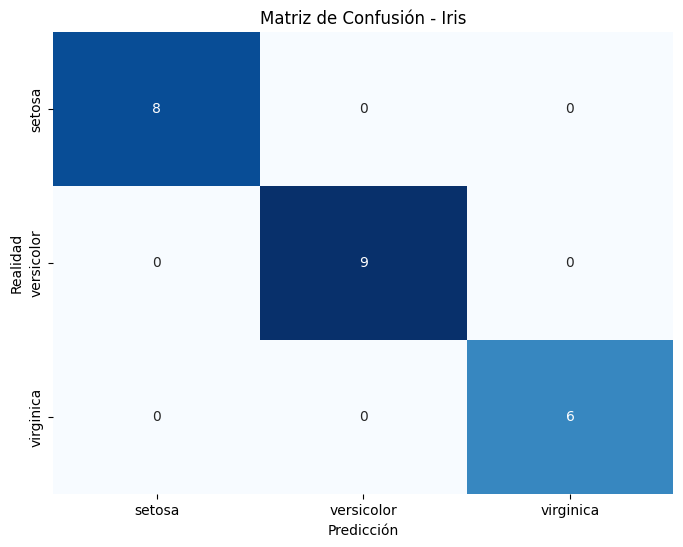

In [ ]:
# Matriz de confusión
cm = confusion_matrix(Y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cbar=False, cmap='Blues',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.title('Matriz de Confusión - Iris')
plt.show()

In [ ]:
print(classification_report(Y_true, y_pred, target_names=encoder.classes_))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00         6

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



In [ ]:
# Vamos a inventar una flor con medidas específicas
# (Largo Sépalo, Ancho Sépalo, Largo Pétalo, Ancho Pétalo)
nueva_flor = np.array([[5.1, 3.5, 1.4, 0.2]])

# Es importante escalar los datos igual que como entrenamos
nueva_flor_norm = scaler.transform(nueva_flor)

# Hacemos la predicción
prediccion = model.predict(nueva_flor_norm)
clase_predicha = np.argmax(prediccion)
nombre_clase = encoder.inverse_transform([clase_predicha])

print(f"Probabilidades por clase: {prediccion}")
print(f"La red dice que esta flor es: {nombre_clase[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Probabilidades por clase: [[9.9999094e-01 8.9377008e-06 6.5981261e-08]]
La red dice que esta flor es: setosa
